
 CLUSTERING USING K-MEDOIDS ALGORITHM 

Prepared By : Arjun Mijar
Roll No.    : 79010160

Do You Want to Start Program? (yes/no)


 yes



    ========== K-MEDOIDS MENU ==========

    1. View Dataset
    2. Apply K-Medoids Algorithm
    0. Exit
    


Enter Your Option:  1



========== DATASET ==========



...


========== APPLYING K-MEDOIDS ALGORITHM ==========



Enter Number of Clusters (K):  3



========== CLUSTERED DATA ==========



,Customer,Income,Spending,Cluster
0,C1,15,39,1
1,C2,16,42,1
2,C3,17,40,1
3,C4,40,70,2
4,C5,42,72,2
5,C6,43,68,2
6,C7,80,20,0
7,C8,85,22,0



Cluster Medoids:

   Income  Spending
0      80        20
1      17        40
2      40        70

========== CLUSTER VISUALIZATION ==========



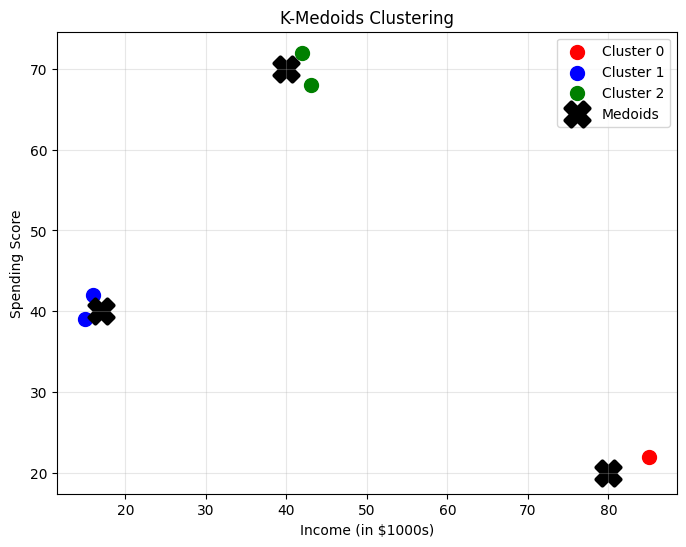


    ========== K-MEDOIDS MENU ==========

    1. View Dataset
    2. Apply K-Medoids Algorithm
    0. Exit
    


Enter Your Option:  0



Program Ended Successfully.


In [5]:
# Demonstration of Clustering using K-Medoids Algorithm

# Prepared By : Arjun Mijar
# Roll No.    : 79010160

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics.pairwise import pairwise_distances
from IPython.display import display_html

# Custom K-Medoids Implementation
class KMedoidsCustom:
    def __init__(self, n_clusters=3, random_state=0, max_iter=100):
        self.n_clusters = n_clusters
        self.random_state = random_state
        self.max_iter = max_iter
        self.labels_ = None
        self.cluster_centers_ = None
    
    def fit(self, X):
        np.random.seed(self.random_state)
        n_samples = X.shape[0]
        
        # Initialize medoids randomly
        medoid_indices = np.random.choice(n_samples, self.n_clusters, replace=False)
        self.medoid_indices_ = medoid_indices.copy()
        
        for _ in range(self.max_iter):
            # Assign clusters based on nearest medoid
            distances = pairwise_distances(X, X[medoid_indices])
            self.labels_ = np.argmin(distances, axis=1)
            
            # Update medoids
            new_medoid_indices = []
            for k in range(self.n_clusters):
                cluster_points = np.where(self.labels_ == k)[0]
                if len(cluster_points) > 0:
                    # Find point with minimum total distance to all points in cluster
                    cluster_distances = pairwise_distances(X[cluster_points], X[cluster_points])
                    min_idx = np.argmin(np.sum(cluster_distances, axis=1))
                    new_medoid_indices.append(cluster_points[min_idx])
                else:
                    new_medoid_indices.append(medoid_indices[k])
            
            # Check convergence
            if np.array_equal(new_medoid_indices, medoid_indices):
                break
            medoid_indices = new_medoid_indices
        
        self.medoid_indices_ = medoid_indices
        self.cluster_centers_ = X[medoid_indices]
        return self

# Function to View Dataset
def view_dataset(data):
    print("\n========== DATASET ==========\n")
    display_html(data)
    print("\nNumber of Rows    :", data.shape[0])
    print("Number of Columns :", data.shape[1])

# Function to Apply K-Medoids Algorithm
def apply_kmedoids(data):
    print("\n========== APPLYING K-MEDOIDS ALGORITHM ==========\n")
    
    # Features for Clustering
    X = data[['Income', 'Spending']].values
    
    # User Input for Number of Clusters
    k = int(input("Enter Number of Clusters (K): "))
    
    # Create K-Medoids Model
    model = KMedoidsCustom(n_clusters=k, random_state=0)
    
    # Train Model
    model.fit(X)
    
    # Assign Cluster Labels
    data['Cluster'] = model.labels_
    
    print("\n========== CLUSTERED DATA ==========\n")
    display_html(data)
    
    # Display Medoids
    print("\nCluster Medoids:\n")
    medoids = pd.DataFrame(model.cluster_centers_,
                           columns=['Income', 'Spending'])
    print(medoids)
    
    # Visualization
    print("\n========== CLUSTER VISUALIZATION ==========\n")
    
    plt.figure(figsize=(8,6))
    
    # Plot clusters
    colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown']
    for i in range(k):
        cluster_data = data[data['Cluster'] == i]
        plt.scatter(cluster_data['Income'],
                    cluster_data['Spending'],
                    c=colors[i % len(colors)],
                    s=100,
                    label=f'Cluster {i}')
    
    # Plot Medoids
    plt.scatter(model.cluster_centers_[:, 0],
                model.cluster_centers_[:, 1],
                marker='X',
                s=300,
                c='black',
                linewidth=3,
                label='Medoids')
    
    plt.xlabel("Income (in $1000s)")
    plt.ylabel("Spending Score")
    plt.title("K-Medoids Clustering")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Menu Function
def menu(data):
    while True:
        print("""
    ========== K-MEDOIDS MENU ==========

    1. View Dataset
    2. Apply K-Medoids Algorithm
    0. Exit
    """)
        
        option = int(input("Enter Your Option: "))
        
        if option == 0:
            break
        elif option == 1:
            view_dataset(data)
        elif option == 2:
            apply_kmedoids(data)
        else:
            print("Please Enter Correct Option.")
    
    print("\nProgram Ended Successfully.")

# Main Function
def main():
    # Sample Dataset
    data = pd.DataFrame({
        'Customer': ['C1', 'C2', 'C3', 'C4',
                     'C5', 'C6', 'C7', 'C8'],
        'Income': [15, 16, 17, 40,
                   42, 43, 80, 85],
        'Spending': [39, 42, 40, 70,
                     72, 68, 20, 22]
    })
    
    print("\n===================================================")
    print(" CLUSTERING USING K-MEDOIDS ALGORITHM ")
    print("===================================================")
    print("\nPrepared By : Arjun Mijar")
    print("Roll No.    : 79010160")
    print("\nDo You Want to Start Program? (yes/no)")
    
    response = input()
    
    if response.lower() == 'yes':
        menu(data)
    else:
        print("\nProgram Terminated.")

# Calling Main Function
if __name__ == "__main__":
    main()